In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm

# the color palette used in the weekly slides
BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

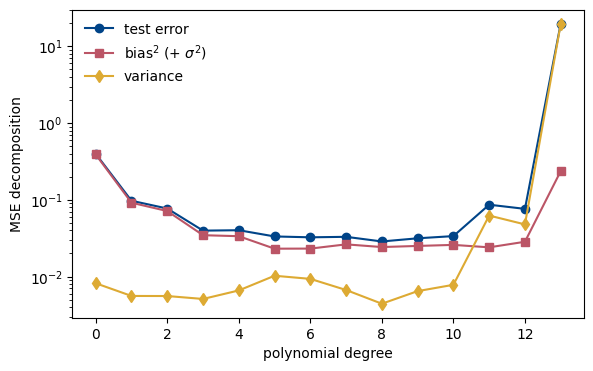

degree  0: error 0.3980  bias^2 0.3898  var 0.0082  sum 0.3980
degree  4: error 0.0401  bias^2 0.0336  var 0.0066  sum 0.0401
degree  8: error 0.0286  bias^2 0.0242  var 0.0044  sum 0.0286
degree 13: error 19.7520  bias^2 0.2367  var 19.5153  sum 19.7520


In [4]:


np.random.seed(2026)
n, n_bootstraps, maxdegree = 40, 100, 14

x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

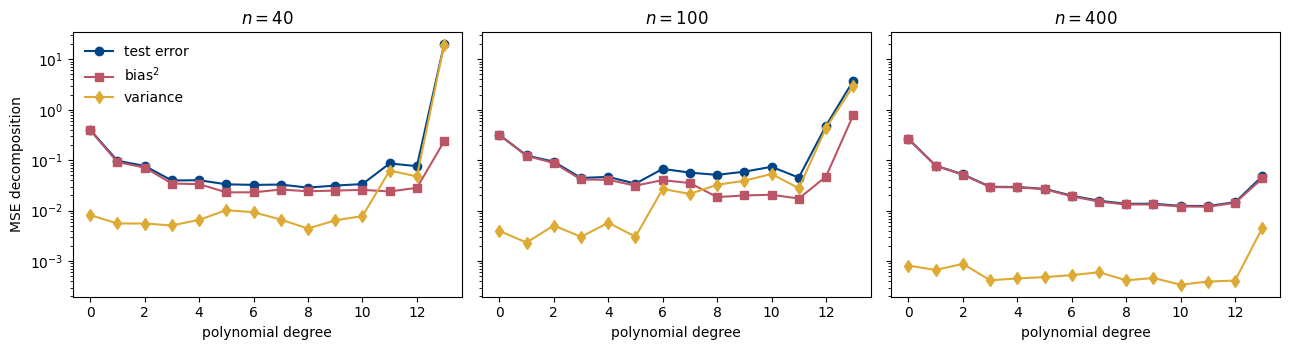

In [5]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

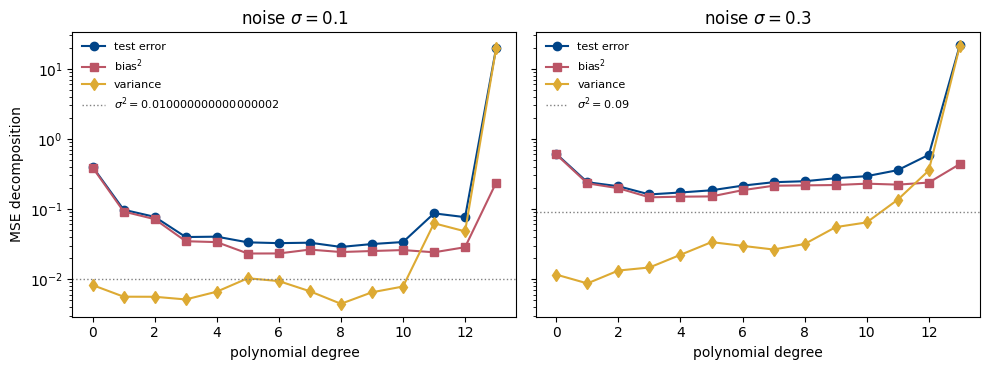

In [6]:


fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, noise_ in zip(axes, (0.1, 0.3)):
    err, b2, var = bias_variance_sweep(n=40, noise=noise_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.axhline(noise_**2, color="gray", ls=":", lw=1,
               label=rf"$\sigma^2 = {noise_**2}$")
    ax.set_yscale("log")
    ax.set_title(rf"noise $\sigma = {noise_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

